# BofA Interview Prep — Options & Derivatives Workshop

**Purpose:** Interview prep for BofA FX Options Technology — CV walkthrough interview.

Your CV claims *"applied understanding of FX dynamics, options payoff structures, and how market data drives derivatives pricing."* This notebook is the evidence base for that claim. Work through every section. Don't skip the exercises — if you can implement it, you can talk about it.

---

### What's covered
- **Part 1** — Options fundamentals refresher (calls, puts, payoff diagrams)
- **Part 2** — Moneyness, intrinsic value, time value
- **Part 3** — Black-Scholes: inputs, intuition, implementation
- **Part 4** — Implied volatility: what it is, how to find it
- **Part 5** — The Greeks: Delta, Gamma, Theta, Vega
- **Part 6** — FX options angle (Garman-Kohlhagen, delta hedging)

---

> **How to use this notebook:**
> - Read the notes cells carefully before touching code
> - Run the example cells to see the output
> - Find every `# YOUR TURN` cell — implement it yourself before looking at the solution
> - The point is not to produce correct output. It's to be able to explain *why* it works.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import norm
from scipy.optimize import brentq

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0f0f0e',
    'axes.facecolor': '#181816',
    'axes.edgecolor': '#333',
    'axes.labelcolor': '#e8e6df',
    'xtick.color': '#7a7870',
    'ytick.color': '#7a7870',
    'text.color': '#e8e6df',
    'grid.color': '#222',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'lines.linewidth': 2,
})

print('Libraries loaded.')

Libraries loaded.


---
## Part 1 — Options Fundamentals

### Notes

An option gives the buyer the **right but not the obligation** to buy or sell an asset at a fixed price (the **strike**, K) at or before expiry. The buyer pays a **premium** upfront. That premium is the maximum they can lose.

**Call option** — right to *buy* at K. You exercise if spot (S) > K, because you can buy cheap and sell at market.
- Payoff at expiry = `max(S - K, 0)`
- Profit = `max(S - K, 0) - premium`

**Put option** — right to *sell* at K. You exercise if S < K, because you can sell above market.
- Payoff at expiry = `max(K - S, 0)`
- Profit = `max(K - S, 0) - premium`

**Key asymmetry:** The buyer's downside is capped at the premium. The seller's (writer's) upside is capped at the premium, but their downside is theoretically unlimited (for calls).

> **Interview anchor:** When your CV says "options payoff structures" this is what it means. The kink at strike K is the most important visual — below/above K the behaviour flips completely.

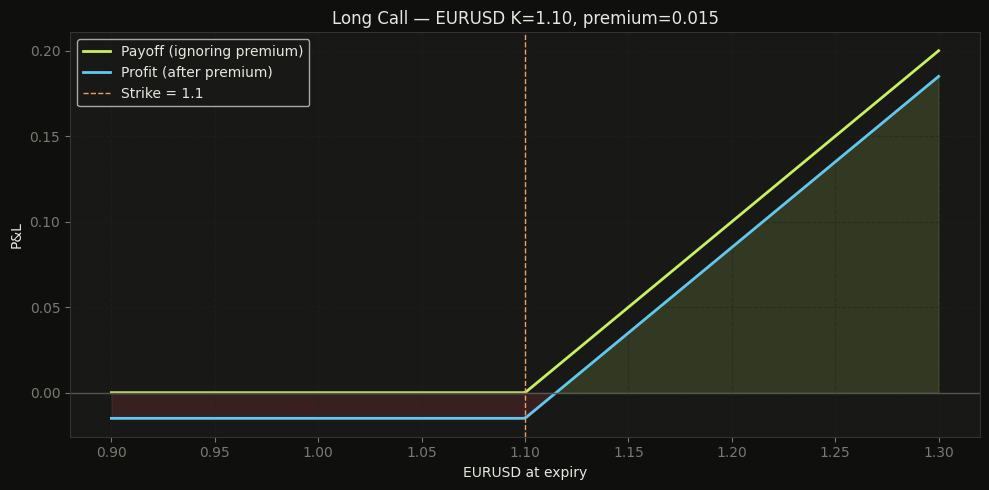

Breakeven: 1.115
Max loss: -0.015 (the premium paid)
Max gain: unlimited — grows linearly above 1.115


In [5]:
# EXAMPLE — long call payoff and profit diagram

S = np.linspace(0.90, 1.30, 300)  # EURUSD spot at expiry
K = 1.10      # strike
premium = 0.015  # cost of the option

call_payoff = np.maximum(S - K, 0)
call_profit = call_payoff - premium

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(S, call_payoff, color='#c8f060', label='Payoff (ignoring premium)')
ax.plot(S, call_profit, color='#60c8f0', label='Profit (after premium)')
ax.axhline(0, color='#555', linewidth=1)
ax.axvline(K, color='#f0a060', linewidth=1, linestyle='--', label=f'Strike = {K}')
ax.fill_between(S, call_profit, 0, where=(call_profit > 0), alpha=0.15, color='#c8f060')
ax.fill_between(S, call_profit, 0, where=(call_profit < 0), alpha=0.15, color='#f05060')
ax.set_xlabel('EURUSD at expiry')
ax.set_ylabel('P&L')
ax.set_title('Long Call — EURUSD K=1.10, premium=0.015')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

print(f'Breakeven: {K + premium:.3f}')
print(f'Max loss: {-premium:.3f} (the premium paid)')
print(f'Max gain: unlimited — grows linearly above {K + premium:.3f}')

### YOUR TURN 1 — Long put payoff diagram

Plot the payoff and profit diagram for a **long put** on EURUSD:
- Spot range: 0.90 to 1.30
- Strike K = 1.10
- Premium = 0.012

Before you code: think about the shape. Where is the kink? Which direction does profit grow?

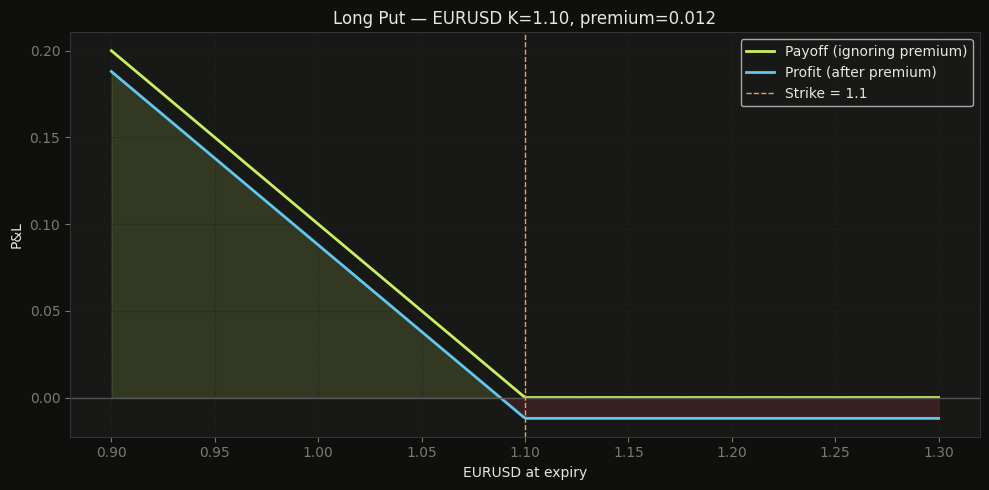

Breakeven: 1.088
Max loss: -0.012 (the premium paid)
Max gain: 1.100 (the strike price)


In [8]:
# YOUR TURN 1 — implement long put payoff and profit

S = np.linspace(0.90, 1.30, 300)
K = 1.10
premium = 0.012

# Your code here:
put_payoff = np.maximum(K - S, 0)  # max(K - S, 0)
put_profit = put_payoff - premium  # payoff minus premium

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(S, put_payoff, color='#c8f060', label='Payoff (ignoring premium)')
ax.plot(S, put_profit, color='#60c8f0', label='Profit (after premium)')
ax.axhline(0, color='#555', linewidth=1)
ax.axvline(K, color='#f0a060', linewidth=1, linestyle='--', label=f'Strike = {K}')
ax.fill_between(S, put_profit, 0, where=(put_profit > 0), alpha=0.15, color='#c8f060')
ax.fill_between(S, put_profit, 0, where=(put_profit < 0), alpha=0.15, color='#f05060')
ax.set_xlabel('EURUSD at expiry')
ax.set_ylabel('P&L')
ax.set_title('Long Put — EURUSD K=1.10, premium=0.012')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()
# Plot it — copy the structure from the call example above
# What's different? What's the max loss? What's the max gain? What's breakeven?
print(f'Breakeven: {K - premium:.3f}')
print(f'Max loss: {-premium:.3f} (the premium paid)')
print(f'Max gain: {K:.3f} (the strike price)')

### YOUR TURN 2 — Straddle (long call + long put, same strike)

A **straddle** is buying both a call and a put at the same strike. It profits from large moves in either direction.

Plot the combined profit on one chart:
- Call: K=1.10, premium=0.015
- Put: K=1.10, premium=0.012
- Combined profit = call_profit + put_profit

Think about: what does this shape look like? When does it profit? Why would a trader use it? (Hint: think about FOMC week, or an NFP release — events where you expect a big move but don't know the direction.)

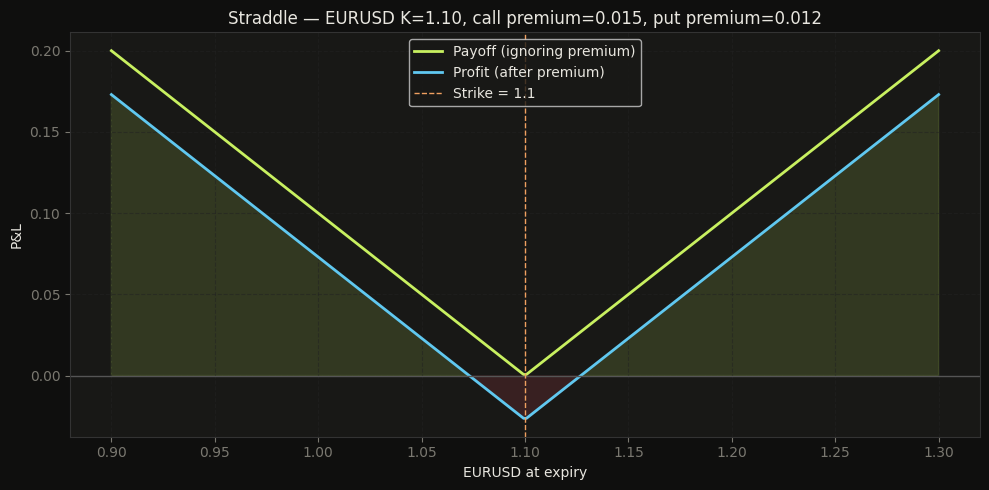

In [11]:
# YOUR TURN 2 — straddle payoff

S = np.linspace(0.90, 1.30, 300)
K = 1.10

call_premium = 0.015
put_premium = 0.012

call_payoff = np.maximum(S - K, 0)
put_payoff = np.maximum(K - S, 0)
straddle_payoff = call_payoff + put_payoff
straddle_profit = straddle_payoff - (call_premium + put_premium)

# it would just be both graphs above combined so either way the big move happens you win, but you pay both premiums so the breakeven points are further apart
# Your code here
# Think about the shape before you plot it
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(S, straddle_payoff, color='#c8f060', label='Payoff (ignoring premium)')
ax.plot(S, straddle_profit, color='#60c8f0', label='Profit (after premium)')
ax.axhline(0, color='#555', linewidth=1)
ax.axvline(K, color='#f0a060', linewidth=1, linestyle='--', label=f'Strike = {K}')
ax.fill_between(S, straddle_profit, 0, where=(straddle_profit > 0), alpha=0.15, color='#c8f060')
ax.fill_between(S, straddle_profit, 0, where=(straddle_profit < 0), alpha=0.15, color='#f05060')
ax.set_xlabel('EURUSD at expiry')
ax.set_ylabel('P&L')
ax.set_title('Straddle — EURUSD K=1.10, call premium=0.015, put premium=0.012')
ax.legend()
ax.grid(True)
plt.tight_layout()

---
## Part 2 — Moneyness, Intrinsic Value & Time Value

### Notes

**Moneyness** describes where spot is relative to strike:

| | Call | Put |
|---|---|---|
| **ITM** (in the money) | S > K | S < K |
| **ATM** (at the money) | S ≈ K | S ≈ K |
| **OTM** (out of the money) | S < K | S > K |

**Option price = Intrinsic value + Time value**

- **Intrinsic value** — what the option is worth if exercised right now. For a call: `max(S - K, 0)`. OTM options have zero intrinsic value.
- **Time value** — the extra amount above intrinsic value, reflecting the possibility that the option moves ITM before expiry. It's always positive (for long options) and always decays toward zero at expiry.

**Why time value exists:** Even an OTM option has value because spot could move in your favour before expiry. The longer the time, the more chances for that to happen. This is what theta eats away at every day.

> **Interview anchor:** When asked about theta decay, this is the mechanism. It's the time value component decaying, not the intrinsic value. An ITM option's intrinsic value doesn't decay — the time value does.

In [10]:
# EXAMPLE — decomposing option price into intrinsic value and time value

def intrinsic_value(S, K, option_type='call'):
    """Intrinsic value — what the option is worth right now if exercised."""
    if option_type == 'call':
        return max(S - K, 0)
    elif option_type == 'put':
        return max(K - S, 0)

def time_value(option_price, S, K, option_type='call'):
    """Time value — the remainder above intrinsic value."""
    return option_price - intrinsic_value(S, K, option_type)

# Example positions:
positions = [
    {'label': 'Deep ITM call', 'S': 1.20, 'K': 1.10, 'price': 0.103, 'type': 'call'},
    {'label': 'ATM call',      'S': 1.10, 'K': 1.10, 'price': 0.035, 'type': 'call'},
    {'label': 'OTM call',      'S': 1.00, 'K': 1.10, 'price': 0.008, 'type': 'call'},
]

print(f'{"Position":<20} {"Price":<10} {"Intrinsic":<12} {"Time Value":<12} {"Moneyness"}')
print('-' * 65)
for p in positions:
    iv = intrinsic_value(p['S'], p['K'], p['type'])
    tv = time_value(p['price'], p['S'], p['K'], p['type'])
    moneyness = 'ITM' if iv > 0 else ('ATM' if p['S'] == p['K'] else 'OTM')
    print(f"{p['label']:<20} {p['price']:<10.3f} {iv:<12.3f} {tv:<12.3f} {moneyness}")

Position             Price      Intrinsic    Time Value   Moneyness
-----------------------------------------------------------------
Deep ITM call        0.103      0.100        0.003        ITM
ATM call             0.035      0.000        0.035        ATM
OTM call             0.008      0.000        0.008        OTM


### YOUR TURN 3 — Classify and decompose

For each position below, without running any code first:
1. Classify it as ITM / ATM / OTM
2. Estimate the intrinsic value
3. Calculate the time value

Then implement the function and verify your answers.

| Position | S | K | Type | Market price |
|---|---|---|---|---|
| A | 1.08 | 1.10 | call | 0.005 |
| B | 1.15 | 1.10 | put  | 0.003 |
| C | 1.10 | 1.10 | call | 0.022 |
| D | 1.05 | 1.10 | put  | 0.058 |

In [12]:
# YOUR TURN 3 — write your predictions first as comments, then verify
positions = [
    {'label': 'A', 'S': 1.08, 'K': 1.10, 'price': 0.005, 'type': 'call'},
    {'label': 'B', 'S': 1.15, 'K': 1.10, 'price': 0.003, 'type': 'put'},
    {'label': 'C', 'S': 1.10, 'K': 1.10, 'price': 0.022, 'type': 'call'},
    {'label': 'D', 'S': 1.05, 'K': 1.10, 'price': 0.058, 'type': 'put'},
]
# A is out the money
# A: S=1.08, K=1.10, call, price=0.005
#    My prediction — Moneyness: OTM, Intrinsic: 0, Time value: 0.005

# B is in the money
# B: S=1.15, K=1.10, put, price=0.003
#    My prediction — Moneyness: ITM, Intrinsic: 0.05, Time value: -0.047

# C is ATM
# C: S=1.10, K=1.10, call, price=0.022
#    My prediction — Moneyness: ATM, Intrinsic: 0, Time value: 0.022

# D deep out the money
# D: S=1.05, K=1.10, put, price=0.058
#    My prediction — Moneyness: OTM, Intrinsic: 0, Time value: 0.058

# Then compute and verify:
print(f'{"Position":<20} {"Price":<10} {"Intrinsic":<12} {"Time Value":<12} {"Moneyness"}')
print('-' * 65)
for p in positions:
    iv = intrinsic_value(p['S'], p['K'], p['type'])
    tv = time_value(p['price'], p['S'], p['K'], p['type'])
    moneyness = 'ITM' if iv > 0 else ('ATM' if p['S'] == p['K'] else 'OTM')
    print(f"{p['label']:<20} {p['price']:<10.3f} {iv:<12.3f} {tv:<12.3f} {moneyness}")


Position             Price      Intrinsic    Time Value   Moneyness
-----------------------------------------------------------------
A                    0.005      0.000        0.005        OTM
B                    0.003      0.000        0.003        OTM
C                    0.022      0.000        0.022        ATM
D                    0.058      0.050        0.008        ITM


---
## Part 3 — Black-Scholes: Inputs, Intuition, Implementation

### Notes

Black-Scholes is a pricing formula that takes 5 inputs and gives you a theoretical fair value for a European option.

**The five inputs:**
- **S** — current spot price
- **K** — strike price
- **T** — time to expiry in years (e.g. 3 months = 0.25)
- **r** — risk-free interest rate (annualised, e.g. 5% = 0.05)
- **σ (sigma)** — volatility (annualised, e.g. 10% = 0.10)

**Key assumptions (for the interview):**
1. The underlying follows a random walk with constant volatility
2. No dividends
3. European exercise only (can only exercise at expiry, not before)
4. No transaction costs
5. Risk-free rate is constant

These assumptions are all violated in practice. Volatility isn't constant (hence the vol surface), markets have transaction costs, and many options are American-style. But BS gives a useful baseline and its Greeks are the industry standard.

**The formula (you don't need to derive this — you need to know the inputs and the output):**
```
d1 = [ln(S/K) + (r + σ²/2)T] / (σ√T)
d2 = d1 - σ√T

Call price = S·N(d1) - K·e^(-rT)·N(d2)
Put price  = K·e^(-rT)·N(-d2) - S·N(-d1)
```
where `N()` is the cumulative normal distribution function.

**Intuition for d1 and d2:**  
`N(d2)` is roughly the probability the option expires ITM. `N(d1)` is delta — the sensitivity of the option price to spot (more on this in Part 5).

> **FX extension — Garman-Kohlhagen:** For FX options, you add a foreign risk-free rate `r_f`. The spot earns the foreign rate, so the formula adjusts: `S` is replaced by `S·e^(-r_f·T)` in the d1/d2 calculations. Same intuition, just accounting for both legs of the currency pair.

In [13]:
# EXAMPLE — Black-Scholes pricing function

def black_scholes(S, K, T, r, sigma, option_type='call'):
    """
    Black-Scholes option price.
    S: spot price
    K: strike
    T: time to expiry in years
    r: risk-free rate (annualised)
    sigma: volatility (annualised)
    option_type: 'call' or 'put'
    """
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

    return price

# ATM EURUSD call, 3 months, 10% vol
price = black_scholes(S=1.10, K=1.10, T=0.25, r=0.04, sigma=0.10, option_type='call')
print(f'ATM call price: {price:.4f}')

# Same option but vol spikes from 10% to 15%
price_high_vol = black_scholes(S=1.10, K=1.10, T=0.25, r=0.04, sigma=0.15, option_type='call')
print(f'ATM call price at 15% vol: {price_high_vol:.4f}')
print(f'Vol spike impact: +{price_high_vol - price:.4f} ({(price_high_vol/price - 1)*100:.1f}% more expensive)')

ATM call price: 0.0277
ATM call price at 15% vol: 0.0385
Vol spike impact: +0.0108 (38.8% more expensive)


### YOUR TURN 4 — Explore how each input moves the price

Use `black_scholes()` to fill in this table manually. For each row, change **only** the labelled input from the baseline. Write down your prediction first, then compute.

**Baseline:** S=1.10, K=1.10, T=0.25, r=0.04, sigma=0.10, call

| Change | Your prediction | Actual price | Direction |
|---|---|---|---|
| Baseline | — | ? | — |
| S → 1.15 (spot moves up) | | | |
| S → 1.05 (spot moves down) | | | |
| T → 0.50 (longer expiry) | | | |
| T → 0.05 (near expiry) | | | |
| sigma → 0.20 (vol doubles) | | | |
| sigma → 0.05 (low vol) | | | |

**The question to ask yourself after each:** *why* did the price move that way? Can you explain the direction without using a formula?

In [ ]:
# YOUR TURN 4 — compute each scenario
baseline = black_scholes(S=1.10, K=1.10, T=0.25, r=0.04, sigma=0.10)
print(f'Baseline: {baseline:.4f}')

# Your computations here:


---
## Part 4 — Implied Volatility

### Notes

Black-Scholes runs forward: inputs → price.  
**Implied volatility runs it backward: market price → vol.**

In practice, options trade at market prices. You can observe S, K, T, and r. Volatility is the one unknown. So you ask: *what value of sigma would make Black-Scholes produce the price I'm observing?* That's implied vol.

**Why it matters:**
- High implied vol = options are expensive = market expects large moves
- Low implied vol = options are cheap = market expects calm
- Around macro events (FOMC, NFP, ECB), implied vol spikes as the market prices in the expected move

**This is what your FX vol feeds at CA-CIB were capturing.** The event vol feed wasn't storing raw option prices — it was storing the implied vol extracted from those prices. That's the standardised, comparable metric. A 1.10 call trading at 0.035 tells you nothing by itself; an implied vol of 9.2% you can compare across strikes, tenors, and time.

**Vol surface:** Implied vol is not the same for every option. It varies by strike (the vol smile/skew) and by expiry. Plot all the implied vols across strikes and tenors and you get the vol surface. If Black-Scholes were perfect, the surface would be flat. It isn't — the market prices OTM puts (downside protection) more expensively than the model suggests, which is why the surface smiles or skews.

> **Interview anchor:** If they ask what your FX vol feeds were, this is the answer. "We captured implied vol data around scheduled macro events — that's the vol extracted from live option prices by inverting a pricing model. It's the standardised metric for comparing option pricing across the market."

In [ ]:
# EXAMPLE — finding implied volatility via numerical solver
# There's no closed-form inverse of BS, so we solve numerically

def implied_vol(market_price, S, K, T, r, option_type='call'):
    """
    Find the implied vol that makes BS price = market_price.
    Uses Brent's method — searches for the sigma that minimises the difference.
    """
    def objective(sigma):
        return black_scholes(S, K, T, r, sigma, option_type) - market_price

    try:
        # Search between 0.1% and 500% vol
        iv = brentq(objective, 0.001, 5.0)
        return iv
    except ValueError:
        return None  # no solution found

# An ATM EURUSD call is trading at 0.035
iv = implied_vol(market_price=0.035, S=1.10, K=1.10, T=0.25, r=0.04)
print(f'Implied vol: {iv:.2%}')

# Verify — plug back in
verify = black_scholes(S=1.10, K=1.10, T=0.25, r=0.04, sigma=iv)
print(f'Verification — BS price at implied vol: {verify:.4f} (should be 0.0350)')

### YOUR TURN 5 — Extract implied vols from a chain of option prices

The table below shows market prices for a series of EURUSD calls across different strikes (all 3-month expiry, S=1.10, r=4%).

| Strike | Market price |
|---|---|
| 1.05 | 0.056 |
| 1.08 | 0.033 |
| 1.10 | 0.023 |
| 1.12 | 0.015 |
| 1.15 | 0.007 |

1. Compute implied vol for each strike
2. Plot implied vol against strike
3. Describe the shape — is it flat? Does it smile or skew? What does that tell you?

In [ ]:
# YOUR TURN 5 — implied vol across the strike chain

strikes =      [1.05, 1.08, 1.10, 1.12, 1.15]
market_prices = [0.056, 0.033, 0.023, 0.015, 0.007]

S = 1.10
T = 0.25
r = 0.04

# Your code here:
# 1. Compute implied vol for each strike
# 2. Plot the vol smile
# 3. In a comment: describe the shape and what it means


---
## Part 5 — The Greeks

### Notes

The Greeks measure how sensitive an option's price is to changes in each input. They are the language traders use to describe and manage risk.

---

### Delta (Δ)
**What it measures:** How much the option price changes for a £1 move in spot.  
**Range:** 0 to +1 for calls, -1 to 0 for puts.  
**ATM options:** delta ≈ ±0.5.  
**Deep ITM:** delta approaches ±1 (moves almost 1:1 with spot).  
**Deep OTM:** delta approaches 0 (barely moves).  

**Trader use — delta hedging:**  
If you're long a call with delta 0.6, you're exposed to spot moving. To neutralise that, you short 0.6 units of the underlying (in FX: sell 0.6 units of the currency pair in spot). Your net delta is zero — you're **delta-neutral**. You no longer care about small spot moves.

> In FX, delta hedging means trading spot. A delta-neutral FX options desk is constantly buying and selling the currency pair to stay neutral.

---

### Gamma (Γ)
**What it measures:** How much **delta** changes for a £1 move in spot (second derivative of price with respect to spot).  
**Always positive** for long options (both calls and puts).  
**Highest:** ATM options near expiry (delta changes fastest here).  

**Trader use:**  
Gamma tells you how often you need to rehedge. High gamma = delta changes quickly = you need to rebalance your delta hedge frequently.  
**Long gamma** is good if the underlying moves a lot — you keep adjusting your hedge in the favourable direction (buy low, sell high in your hedging trades).  

---

### Theta (Θ)
**What it measures:** How much the option price falls per day, all else equal.  
**Always negative** for long options — you lose value every day you hold them.  
**Highest (fastest decay):** ATM options near expiry.  

**The Gamma-Theta relationship — the central trade-off:**  
Long options = **long gamma** (benefits from big moves) + **short theta** (bleeds value daily).  
You are paying the daily theta bleed in exchange for the right to benefit from a large move.  
Short options = the reverse: you collect theta daily but are short gamma (hurt by big moves).

---

### Vega (ν)
**What it measures:** How much the option price changes for a 1% move in implied volatility.  
**Always positive** for long options — higher vol = more expensive options.  
**Highest:** ATM options with long time to expiry (most time for vol to play out).  

**Trader use:**  
If you think vol is going to spike (e.g. before an FOMC announcement), you want to be long vega — buy options. If vol is elevated and you think it'll fall, short vega — sell options.  
Around macro events, vol typically spikes before the event and collapses immediately after (the uncertainty resolves). Traders often buy vol before the event and sell it as it spikes.

---

**The summary relationship:**
```
Long option = +Gamma  +Vega  −Theta
Short option = −Gamma  −Vega  +Theta
```
> **This is the most important thing to remember for the interview.** If they ask about any Greek, anchor back to this relationship. The Greeks are not independent — they're a package deal.

In [ ]:
# EXAMPLE — analytical Greeks for a BS option

def bs_greeks(S, K, T, r, sigma, option_type='call'):
    """Compute all major Greeks analytically."""
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    # Delta
    if option_type == 'call':
        delta = norm.cdf(d1)
    else:
        delta = norm.cdf(d1) - 1   # same as -N(-d1)

    # Gamma (same for calls and puts)
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))

    # Theta (per calendar day, not per year)
    if option_type == 'call':
        theta = (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
                 - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
    else:
        theta = (-(S * norm.pdf(d1) * sigma) / (2 * np.sqrt(T))
                 + r * K * np.exp(-r * T) * norm.cdf(-d2)) / 365

    # Vega (per 1% move in vol)
    vega = S * norm.pdf(d1) * np.sqrt(T) * 0.01

    return {'delta': delta, 'gamma': gamma, 'theta': theta, 'vega': vega}

# ATM call
g = bs_greeks(S=1.10, K=1.10, T=0.25, r=0.04, sigma=0.10, option_type='call')
print('ATM Call — S=1.10, K=1.10, T=0.25, sigma=10%')
print(f"  Delta: {g['delta']:.4f}  — spot moves £1, option moves {g['delta']:.4f}")
print(f"  Gamma: {g['gamma']:.4f}  — delta changes by {g['gamma']:.4f} per £1 spot move")
print(f"  Theta: {g['theta']:.4f}  — option loses {abs(g['theta']):.4f} per day (time decay)")
print(f"  Vega:  {g['vega']:.4f}  — option gains {g['vega']:.4f} per 1% rise in implied vol")

### YOUR TURN 6 — Delta across moneyness

Plot delta for a **call** option as spot varies from 0.90 to 1.30 (K=1.10, T=0.25, r=0.04, sigma=0.10).

Before you code: sketch the shape in your head.
- Deep OTM call (S=0.90): what should delta be?
- ATM call (S=1.10): what should delta be?
- Deep ITM call (S=1.30): what should delta be?
- What does the transition look like — sharp or gradual?

This is the delta transition at strike — it's why the payoff diagram has a kink at K.

In [ ]:
# YOUR TURN 6 — delta across spot range

S_range = np.linspace(0.90, 1.30, 200)
K = 1.10
T = 0.25
r = 0.04
sigma = 0.10

# Your code here:
# Compute delta for each S in S_range, then plot
# Label: the strike, the 0.5 delta point, and the 0/1 asymptotes


### YOUR TURN 7 — Interpret a position's Greeks

You have the following FX options position. Using `bs_greeks()`, compute the Greeks for each leg, then answer the questions below.

| Leg | Type | S | K | T | sigma | Size |
|---|---|---|---|---|---|---|
| A | Long call | 1.10 | 1.10 | 0.25 | 0.10 | +1 |
| B | Short call | 1.10 | 1.15 | 0.25 | 0.10 | -1 |

This is a **bull spread** — long the ATM call, short the OTM call.

Questions (answer in comments before running the code):
1. Is the net delta positive or negative? What does that mean?
2. Is the net gamma positive or negative? Are you hurt or helped by large spot moves?
3. Is the net theta positive or negative? Are you collecting or paying time decay daily?
4. Is the net vega positive or negative? Do you benefit if implied vol rises?

In [ ]:
# YOUR TURN 7 — bull spread Greeks

# My predictions (answer before computing):
# 1. Net delta: ?
# 2. Net gamma: ?
# 3. Net theta: ?
# 4. Net vega: ?

leg_a = bs_greeks(S=1.10, K=1.10, T=0.25, r=0.04, sigma=0.10, option_type='call')
leg_b = bs_greeks(S=1.10, K=1.15, T=0.25, r=0.04, sigma=0.10, option_type='call')

# Net position = long leg_a, short leg_b
# Compute net Greeks and print them
# Were your predictions right?


---
## Part 6 — FX Options Angle

### Notes

Everything above applies to equity options. For FX options, a few things are different:

**Two risk-free rates:** In an equity option, you have one risk-free rate (domestic). In FX, both legs of the pair earn interest. A EURUSD option is priced using both the USD rate (domestic) and the EUR rate (foreign). The Garman-Kohlhagen model handles this by discounting the spot price by the foreign rate: `S·e^(-r_f·T)` replaces bare `S` in the calculations.

**Delta hedging means trading spot FX:** If you're delta hedging a EURUSD options book, the hedge is buying or selling EURUSD in the spot market. Not futures, not forwards — spot. The delta tells you exactly how much.

**Vol quoting conventions:** FX options are typically quoted in implied vol (not price). A trader saying "EURUSD 3-month ATM vol is 7.5%" means the ATM implied vol is 7.5%. They then use that to compute a price. This is why your vol feeds at CA-CIB stored implied vol rather than raw option prices — it's the standard quoting convention.

**Put-call parity:** For European options, there's a strict no-arbitrage relationship:
```
C - P = S·e^(-r_f·T) - K·e^(-r·T)
```
If this doesn't hold, there's a free money trade. In practice it holds tightly because arbitrageurs enforce it.

In [ ]:
# EXAMPLE — Garman-Kohlhagen for FX options

def garman_kohlhagen(S, K, T, r_d, r_f, sigma, option_type='call'):
    """
    Garman-Kohlhagen pricing for FX European options.
    r_d: domestic risk-free rate
    r_f: foreign risk-free rate
    """
    d1 = (np.log(S / K) + (r_d - r_f + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)

    if option_type == 'call':
        price = (S * np.exp(-r_f * T) * norm.cdf(d1)
                 - K * np.exp(-r_d * T) * norm.cdf(d2))
    elif option_type == 'put':
        price = (K * np.exp(-r_d * T) * norm.cdf(-d2)
                 - S * np.exp(-r_f * T) * norm.cdf(-d1))

    return price

# EURUSD call: USD rates = 5%, EUR rates = 3.5%, vol = 8%
call_price = garman_kohlhagen(S=1.10, K=1.10, T=0.25, r_d=0.05, r_f=0.035, sigma=0.08)
put_price  = garman_kohlhagen(S=1.10, K=1.10, T=0.25, r_d=0.05, r_f=0.035, sigma=0.08, option_type='put')

print(f'ATM EURUSD Call: {call_price:.4f}')
print(f'ATM EURUSD Put:  {put_price:.4f}')

# Put-call parity check
T, r_d, r_f, S, K = 0.25, 0.05, 0.035, 1.10, 1.10
lhs = call_price - put_price
rhs = S * np.exp(-r_f * T) - K * np.exp(-r_d * T)
print(f'\nPut-call parity check: C-P = {lhs:.4f}, Se^(-rf·T) - Ke^(-rd·T) = {rhs:.4f}')
print(f'Holds: {np.isclose(lhs, rhs)}')

### YOUR TURN 8 — Impact of interest rate differential on FX option price

Use `garman_kohlhagen()` to explore how the interest rate differential between USD and EUR affects the ATM call price.

Baseline: S=1.10, K=1.10, T=0.25, sigma=0.08, r_d=0.05, r_f=0.035

1. Plot call price as `r_f` varies from 0% to 8% (keep r_d fixed at 5%)
2. At what foreign rate does the call price hit its minimum?
3. Explain the direction: when EUR rates are higher, what happens to the call price and why?

Think about this from first principles: if EUR yields more, holding EUR is more attractive — what does that do to demand for the right to *buy* EUR (a call)?

In [ ]:
# YOUR TURN 8 — interest rate differential effect

r_f_range = np.linspace(0.00, 0.08, 100)

# Your code here:
# 1. Compute call price at each r_f
# 2. Plot
# 3. In a comment: explain the direction


---
## Interview Anchor — Key Talking Points

These are the things to be able to say fluently in the interview. Don't memorise — *understand* them so you can reconstruct them under pressure.

**On your FX vol feeds:**
> "We captured implied vol data around scheduled macro events — FOMC, NFP, ECB decisions. Implied vol is extracted from live option prices by inverting a pricing model like Black-Scholes. It's the market's forward-looking estimate of how much the pair will move. We stored vol rather than raw prices because vol is the standardised, comparable metric — a call price of 0.035 tells you nothing in isolation; an implied vol of 9% you can compare across tenors and strikes."

**On the Greeks:**
> "Delta is the first-order sensitivity to spot — how much the option price moves per unit move in the underlying. For an FX options desk, delta hedging means trading spot currency to stay neutral. Gamma tells you how quickly delta itself changes — high gamma near expiry means you're rehedging frequently. Theta is the daily time decay you pay for holding long options. Vega is your exposure to implied vol — long options are long vega, so if vol spikes ahead of an FOMC you benefit. The key relationship: long options means you're long gamma and vega but short theta. You're paying daily bleed for the right to benefit from large moves and rising vol."

**On Black-Scholes:**
> "Black-Scholes takes five inputs — spot, strike, expiry, rates, and vol — and outputs a fair value. For FX you use Garman-Kohlhagen, which adds a foreign risk-free rate since both currencies earn interest. Volatility is the only input you can't observe directly, which is why implied vol matters — it's what the model needs to match the observed market price."

**On put-call parity:**
> "Put-call parity is a no-arbitrage constraint: C - P = discounted spot minus discounted strike. If it breaks, there's a free money trade and arb desks enforce it immediately. In practice it holds tightly."

---

## Self-Check Quiz

Answer these without looking up anything. Write your answers in the cell below. If you get stuck on one, that's the thing to revisit.

1. EURUSD is at 1.10. You hold a call with strike 1.15, expiry in 2 weeks. Implied vol spikes from 8% to 14% the day before NFP. Does your option gain or lose value? Why?

2. You're long an ATM EURUSD call with delta 0.52. How do you delta-hedge it? What instrument do you use in FX?

3. Gamma is highest for which options? Why does that matter to a trader running a delta-neutral book?

4. An option's market price is 0.028. You compute the BS price at 10% vol and get 0.021. What does that tell you about where implied vol actually is — above or below 10%?

5. Your CV says you built "FX volatility event feeds." The interviewer asks what that means technically. What do you say?

In [ ]:
# Self-check answers — write them here before running anything

# Q1:

# Q2:

# Q3:

# Q4:

# Q5:
